<a href="https://colab.research.google.com/github/emreyilmvz/Titanic-Yolcu-Veri-Seti-Hayatta-Kalma-Tahmini/blob/main/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Yolcu Veri Seti: Hayatta Kalma Tahmini
## 1. Kütüphanelerin ve Verinin Yüklenmesi
İlk adımımız veri işleme (Pandas), matematiksel işlemler (NumPy), görselleştirme (Matplotlib, Seaborn) ve makine öğrenmesi (Sklearn) araçlarını projemize dahil etmektir.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# veriyi yüklüyoruz
df = pd.read_csv('train.csv')

# veriyi ilk inceleme
print("Veri Seti Boyutu:", df.shape)
df.head()

Veri Seti Boyutu: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 2. Veri Setinin Türkçeleştirilmesi
## Sunumda anlaşılırlığı artırmak adına değişken isimlerini yerel dilimize uyarlıyoruz. Bu aşama teknik bir zorunluluk olmasa da veriye hakimiyeti göstermesi açısından önemlidir.

In [ ]:
# sütun isimlerini Türkçeleştirme (gerekli değil kendim daha rahat ettiğim için yapıyorum)
yeni_isimler = {
    'PassengerId': 'YolcuID',
    'Survived': 'HayattaKalma',
    'Pclass': 'YolcuSinifi',
    'Name': 'Isim',
    'Sex': 'Cinsiyet',
    'Age': 'Yas',
    'SibSp': 'KardesEs_Sayisi',
    'Parch': 'EbeveynCocuk_Sayisi',
    'Ticket': 'BiletNo',
    'Fare': 'BiletUcreti',
    'Cabin': 'Kabin',
    'Embarked': 'BinisLimani'
}

# isim değişikliği
df.rename(columns=yeni_isimler, inplace=True)
df.columns

Index(['YolcuID', 'HayattaKalma', 'YolcuSinifi', 'Isim', 'Cinsiyet', 'Yas',
       'KardesEs_Sayisi', 'EbeveynCocuk_Sayisi', 'BiletNo', 'BiletUcreti',
       'Kabin', 'BinisLimani'],
      dtype='object')

# 3. Ön Veri Analizi
## Hedef değişkenimiz olan `HayattaKalma` durumunu, en etkili olduğunu düşündüğümüz `Cinsiyet` ve `YolcuSinifi` bağlamında inceliyoruz.

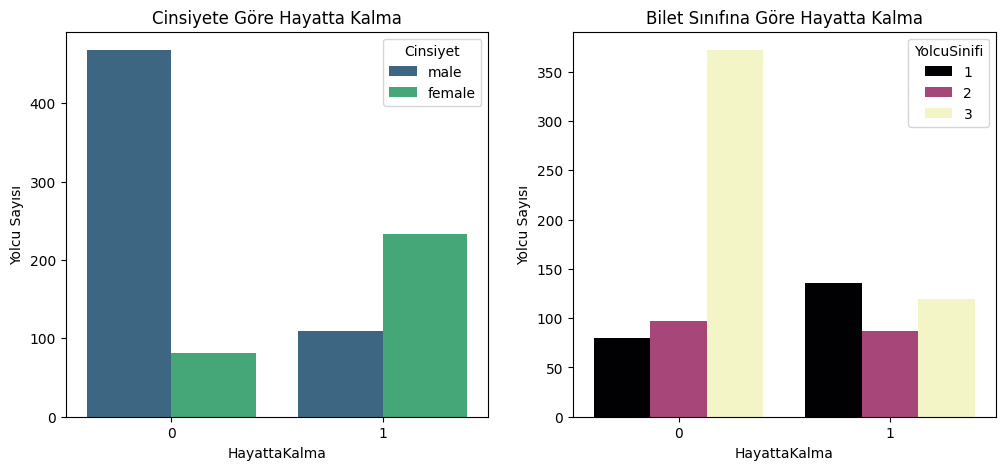

In [ ]:
# hayatta kalma oranı için grafik
plt.figure(figsize=(12, 5))

# cinsiyet
plt.subplot(1, 2, 1)
sns.countplot(x='HayattaKalma', hue='Cinsiyet', data=df, palette='viridis')
plt.title('Cinsiyete Göre Hayatta Kalma')
plt.ylabel('Yolcu Sayısı')

# bilet sınıfı
plt.subplot(1, 2, 2)
sns.countplot(x='HayattaKalma', hue='YolcuSinifi', data=df, palette='magma')
plt.title('Bilet Sınıfına Göre Hayatta Kalma')
plt.ylabel('Yolcu Sayısı')

plt.show()

# 4. Veri Temizleme: Eksik Verilerin Doldurulması
## Boş veriler (NaN) modelimizin çalışmasını engelleyeceği için bunları mantıklı değerlerle dolduruyoruz.

Yaş sütununu doldururken ortalama (mean) yerine neden medyan (median) kullandık? Çünkü veri setinde 1-2 tane çok yaşlı yolcu olması, ortalamayı anlamsız şekilde yukarı çeker (Aykırı Değer/Outlier etkisi). Medyan, verinin "tam ortasını" aldığı için çok daha güvenilir bir yaklaşımdır.


In [ ]:
# eksik veri kontrolü
print("Eksik Veriler:\n", df.isnull().sum())

# yaş sütununu medyan ile doldurma
df['Yas'] = df['Yas'].fillna(df['Yas'].median())

# biniş limanı sütununu mode ile doldurma (en çok tekrar eden)
df['BinisLimani'] = df['BinisLimani'].fillna(df['BinisLimani'].mode()[0])

# tekrar eksik veri kontrolü
print("\nTemizlik Sonrası Eksik Veriler:\n", df.isnull().sum())
print("\nEksik veriler dolduruldu.")

Eksik Veriler:
 YolcuID                  0
HayattaKalma             0
YolcuSinifi              0
Isim                     0
Cinsiyet                 0
Yas                    177
KardesEs_Sayisi          0
EbeveynCocuk_Sayisi      0
BiletNo                  0
BiletUcreti              0
Kabin                  687
BinisLimani              2
dtype: int64

Temizlik Sonrası Eksik Veriler:
 YolcuID                  0
HayattaKalma             0
YolcuSinifi              0
Isim                     0
Cinsiyet                 0
Yas                      0
KardesEs_Sayisi          0
EbeveynCocuk_Sayisi      0
BiletNo                  0
BiletUcreti              0
Kabin                  687
BinisLimani              0
dtype: int64

Eksik veriler dolduruldu.


# 5. Özellik Seçimi
## Modelin "genel kurallar" öğrenebilmesi için, kişiye özel (eşsiz) veya çok büyük bir kısmı boş olan verileri veri setinden uzaklaştırıyoruz.

In [ ]:
# gereksiz sütunları atıyoruz
# kabin çok fazla eksik içerdiği için, diğerleri ise eşsiz olduğu için atıldı.
df_clean = df.drop(['YolcuID', 'Isim', 'BiletNo', 'Kabin'], axis=1)

print("Kalan Sütunlar:", df_clean.columns.tolist())
df_clean.head()

Kalan Sütunlar: ['HayattaKalma', 'YolcuSinifi', 'Cinsiyet', 'Yas', 'KardesEs_Sayisi', 'EbeveynCocuk_Sayisi', 'BiletUcreti', 'BinisLimani']


,HayattaKalma,YolcuSinifi,Cinsiyet,Yas,KardesEs_Sayisi,EbeveynCocuk_Sayisi,BiletUcreti,BinisLimani
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# 6. Veri Önişleme (Label Encoding)
## Karar Ağacı algoritması metinleri okuyamaz. Bu sebeple "Cinsiyet" ve "Biniş Limanı" gibi kelimeleri `LabelEncoder` yardımıyla sayılara dönüştürüyoruz.

In [ ]:
le = LabelEncoder()

# cinsiyet: erkek -> 1, kadın -> 0
df_clean['Cinsiyet'] = le.fit_transform(df_clean['Cinsiyet'])

# limanlar: S -> 2, C -> 0, Q -> 1
df_clean['BinisLimani'] = le.fit_transform(df_clean['BinisLimani'])

# artık tüm veriler sayısal
df_clean.head()

,HayattaKalma,YolcuSinifi,Cinsiyet,Yas,KardesEs_Sayisi,EbeveynCocuk_Sayisi,BiletUcreti,BinisLimani
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


# 7. Eğitim ve Test Setlerini ayırma
## Modelin başarısını gerçekçi bir şekilde ölçebilmek için, öğrenme sürecinde kullanmadığımız (görmediği) verilerle onu test etmeliyiz. Veriyi %80 Eğitim, %20 Test olacak şekilde ayırıyoruz.

In [ ]:
# X: özellikler, y: hedef değişken (HayattaKalma)
X = df_clean.drop('HayattaKalma', axis=1)
y = df_clean['HayattaKalma']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=14)

print(f"Eğitim Verisi: {X_train.shape[0]} satır")
print(f"Test Verisi: {X_test.shape[0]} satır")

Eğitim Verisi: 712 satır
Test Verisi: 179 satır


# 8. Makine Öğrenmesi Modeli
## Sınıflandırma algoritması olarak Karar Ağacı'nı kuruyor ve eğitim verilerimizle öğrenme sürecini başlatıyoruz.

In [ ]:
# modeli tanımlama
model = DecisionTreeClassifier(random_state=42)

# model eğitimi
model.fit(X_train, y_train)

# tahmin zamanı
y_pred = model.predict(X_test)

# 9. Sonuçlar ve Performans Analizi
## Modelimizin test verileri üzerindeki tahmin yeteneğini değerlendiriyoruz.


Model Doğruluk Oranı (Accuracy): %81.56



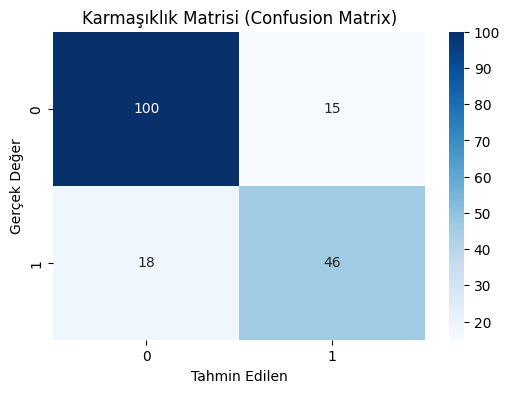


Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86       115
           1       0.75      0.72      0.74        64

    accuracy                           0.82       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179



In [ ]:
# başarı oranı
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluk Oranı (Accuracy): %{accuracy*100:.2f}\n")

# confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()

# final rapor
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))